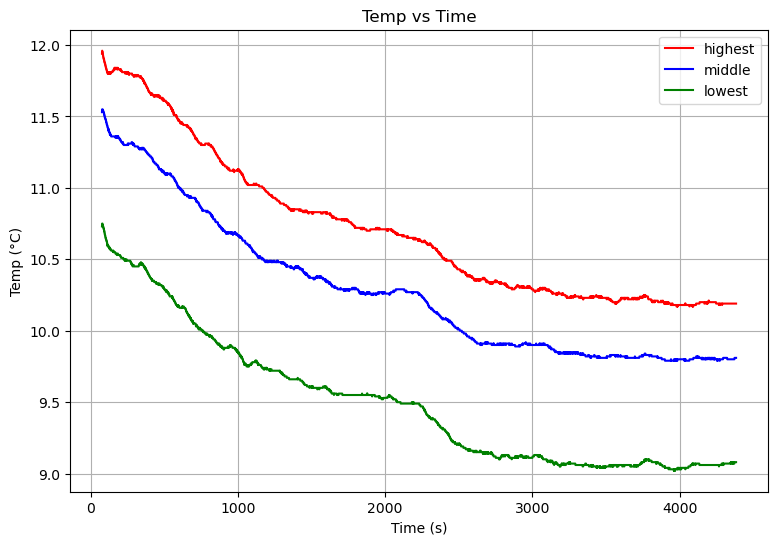

In [98]:
import numpy as np
import matplotlib.pyplot as plt

# Be sure to use the cleaner to clean all files prior to process

tracker = "no_epaper_cooled_3-13_cleaned.csv"
tracker_data = np.genfromtxt(tracker, skip_header=1, delimiter=',')

t       = tracker_data[:, 0]
highest = tracker_data[:, 1]
middle  = tracker_data[:, 2]
lowest  = tracker_data[:, 3]
#surface  = tracker_data[:, 6]

# Moving average
window_size = 500
t_ma = t[window_size - 1:]

moving_average_highest = []
moving_average_middle  = []
moving_average_lowest  = []
moving_average_surface  = []

i = 0
while i < len(t) - window_size + 1:
    moving_average_highest.append(round(np.nanmean(highest[i : i + window_size]), 2))
    moving_average_middle.append(round(np.nanmean(middle[i  : i + window_size]), 2))
    moving_average_lowest.append(round(np.nanmean(lowest[i  : i + window_size]), 2))
    #moving_average_surface.append(round(np.nanmean(surface[i  : i + window_size]), 2))
    i += 1
    

diff = np.array(moving_average_highest)-np.array(moving_average_lowest)
# Plot
plt.figure(figsize=(9, 6))
plt.plot(t_ma, moving_average_highest, 'r', label='highest')
plt.plot(t_ma, moving_average_middle,  'b', label='middle')
plt.plot(t_ma, moving_average_lowest,  'g', label='lowest')
#plt.plot(t_ma, moving_average_surface,  'y', label='surface')
#plt.plot(t_ma, diff,  'y', label='diff')
plt.title('Temp vs Time')
plt.xlabel('Time (s)')
plt.ylabel('Temp (°C)')
plt.legend()
plt.grid()
plt.show()



In [102]:
#independant channel
tracker = "no_epaper_cooled_3-13_cleaned.csv"
tracker_data = np.genfromtxt(tracker, skip_header=1, delimiter=',')

t       = tracker_data[:, 0]
highest = tracker_data[:, 1]
middle  = tracker_data[:, 2]
lowest  = tracker_data[:, 3]



#finding heat flux [W/m/m]
calibration = "thermalcouple_calibration_cleaned.csv"
calibration_data = np.genfromtxt(calibration, skip_header=1, delimiter=',')

k = 115 #Heat conduction through brass 360 [W/m/k]
d = 0.015 #distance between each thermal couple [m]
cal1 = np.nanmedian(calibration_data[:,1]) # calibration of couple 1 (high)
cal2 = np.nanmedian(calibration_data[:,2]) # calibration of couple 2 (middle)
cal3 = np.nanmedian(calibration_data[:,3]) # calibration of couple 3 (low)

T1 = np.nanmin(highest) - cal1
T2 = np.nanmin(middle) - cal2
T3 = np.nanmin(lowest) - cal3

Q12 = k*(T1-T2)/d
Q13 = k*(T1-T3)/(2*d)
Q23 = k*(T2-T3)/d

print(f"T1raw = {np.nanmin(highest)}")
print(f"T2raw = {np.nanmin(middle)}")
print(f"T3raw = {np.nanmin(lowest)}")

print(f"cal1 = {cal1}")
print(f"cal2 = {cal2}")
print(f"cal3 = {cal3}")

print(f"T1 = {T1}")
print(f"T2 = {T2}")
print(f"T3 = {T3}")

print(f"Heat flux through 1 and 2 = {Q12}")
print(f"Heat flux through 1 and 3 = {Q13}")
print(f"Heat flux through 2 and 3 = {Q23}")

print(f"Temperature data from {tracker}")
print(f"Calibration data from {calibration}")


    # note to self
    # no_epaper_cooled_3-13_cleaned.csv + Calibration_cleaned.csv
    # Heat flux through 1 and 2 = 1456.666666666663
    # Heat flux through 1 and 3 = 1648.3333333333323
    # Heat flux through 2 and 3 = 1840.0000000000016
    
    # 3-25_lighton_superclose-contact_cleaned.csv + calibration_3-25cleaned.csv
    # Heat flux through 1 and 2 = 6210.000000000005
    # Heat flux through 1 and 3 = 5980.000000000003
    # Heat flux through 2 and 3 = 5750.0

    





T1raw = 9.81
T2raw = 9.06
T3raw = 8.75
cal1 = -0.56
cal2 = -0.19
cal3 = -0.37
T1 = 10.370000000000001
T2 = 9.25
T3 = 9.12
Heat flux through 1 and 2 = 8586.666666666675
Heat flux through 1 and 3 = 4791.666666666673
Heat flux through 2 and 3 = 996.6666666666727
Temperature data from no_epaper_cooled_3-13_cleaned.csv
Calibration data from thermalcouple_calibration_cleaned.csv
